<a href="https://colab.research.google.com/github/KhaledMahaMudRajon/LinearRegressionForAI-ML/blob/main/220110(logisticRegression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load and Explore the Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

# Load data (adjust path after mounting Google Drive)
df = pd.read_csv('/content/drive/MyDrive/Teen_Mental_Health_Dataset.csv')
print(df.shape)
df.head()

(1200, 13)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


Check missing values:



In [ ]:
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


Data Exploration

1. BASIC INFO
Dataset shape: (1200, 13)

First 5 rows:
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0  

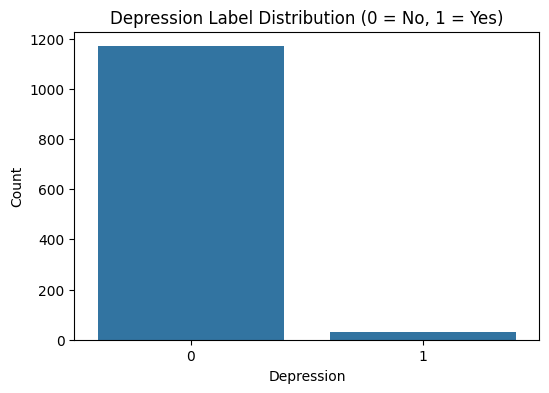

Class imbalance ratio (minority/majority): 0.03
⚠️ Warning: Dataset is imbalanced. Consider class_weight='balanced' later.

4. NUMERICAL FEATURE ANALYSIS

--- age ---
  Min: 13, Max: 19, Mean: 15.93, Std: 2.02

--- daily_social_media_hours ---
  Min: 1.0, Max: 8.0, Mean: 4.54, Std: 2.03

--- sleep_hours ---
  Min: 4.0, Max: 9.0, Mean: 6.45, Std: 1.44

--- screen_time_before_sleep ---
  Min: 0.5, Max: 3.0, Mean: 1.74, Std: 0.72

--- academic_performance ---
  Min: 2.0, Max: 4.0, Mean: 2.99, Std: 0.58

--- physical_activity ---
  Min: 0.0, Max: 2.0, Mean: 1.01, Std: 0.58

--- stress_level ---
  Min: 1, Max: 10, Mean: 5.45, Std: 2.90

--- anxiety_level ---
  Min: 1, Max: 10, Mean: 5.64, Std: 2.86

--- addiction_level ---
  Min: 1, Max: 10, Mean: 5.57, Std: 2.83


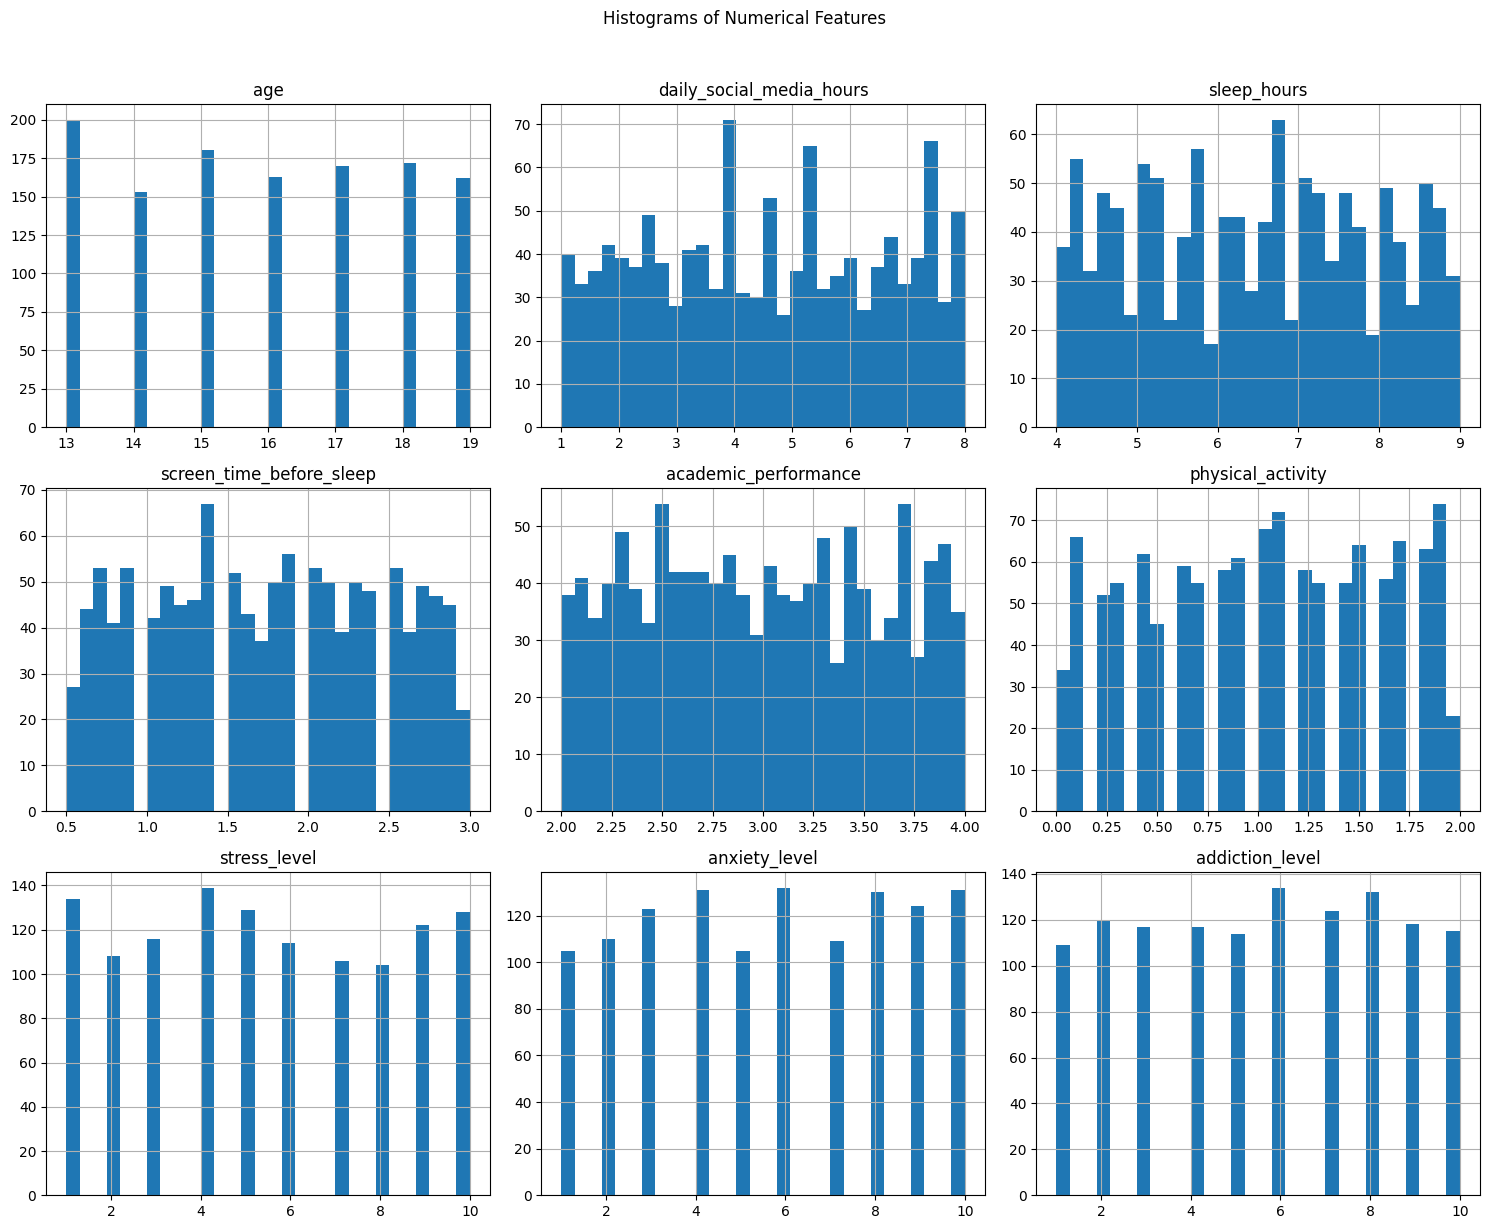

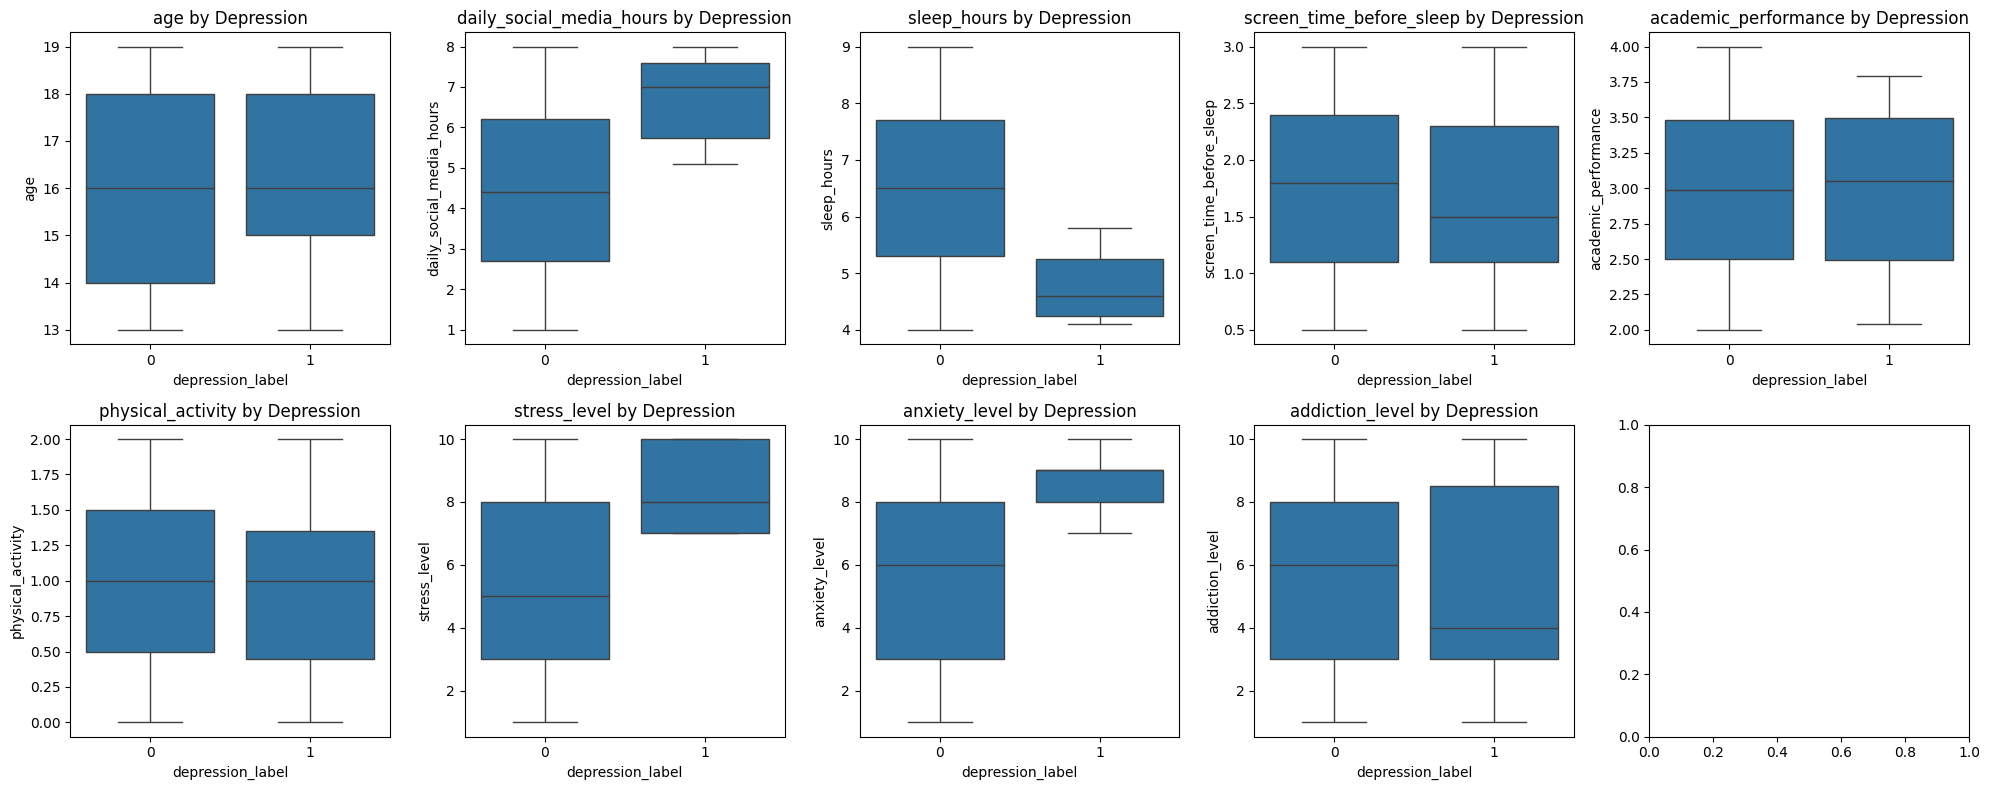


5. CATEGORICAL FEATURE ANALYSIS

--- gender ---
Unique values: 2
Value counts:
gender
male      615
female    585
Name: count, dtype: int64

Depression percentage by gender:
depression_label          0         1
gender                               
female            97.094017  2.905983
male              97.723577  2.276423


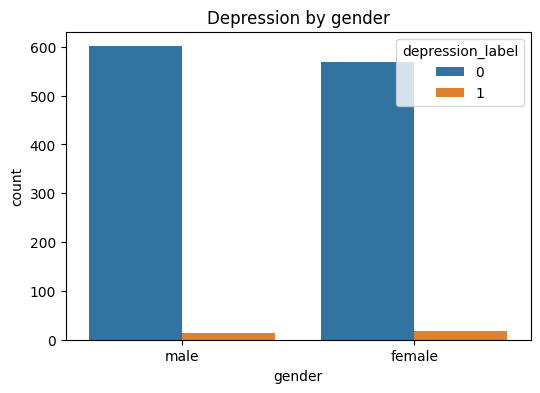


--- platform_usage ---
Unique values: 3
Value counts:
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

Depression percentage by platform_usage:
depression_label          0         1
platform_usage                       
Both              97.698210  2.301790
Instagram         97.566910  2.433090
TikTok            96.984925  3.015075


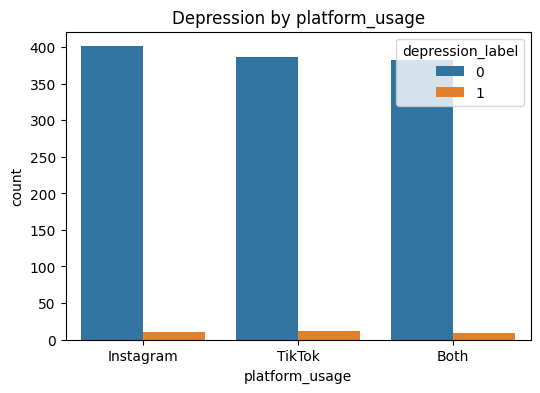


--- social_interaction_level ---
Unique values: 3
Value counts:
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

Depression percentage by social_interaction_level:
depression_label                  0         1
social_interaction_level                     
high                      97.289973  2.710027
low                       97.831325  2.168675
medium                    97.115385  2.884615


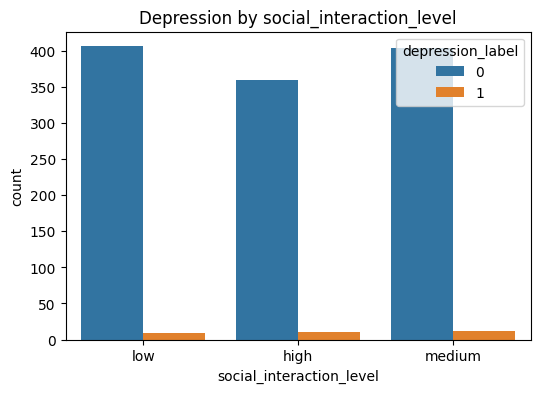


6. CORRELATION MATRIX (Numerical features)


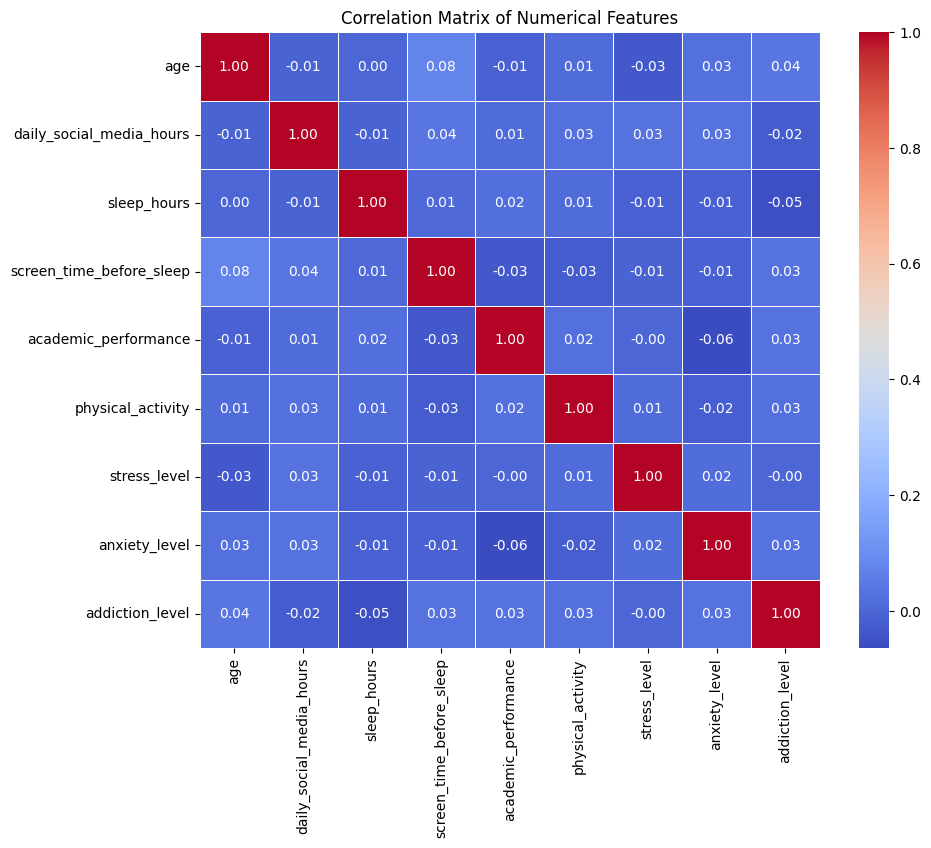


Point-biserial correlation with depression_label:
age                       : 0.011 (p=0.7042)
daily_social_media_hours  : 0.175 (p=0.0000)
sleep_hours               : -0.191 (p=0.0000)
screen_time_before_sleep  : -0.017 (p=0.5679)
academic_performance      : 0.001 (p=0.9602)
physical_activity         : -0.018 (p=0.5425)
stress_level              : 0.170 (p=0.0000)
anxiety_level             : 0.170 (p=0.0000)
addiction_level           : -0.014 (p=0.6292)

7. CHECK FOR DUPLICATES
Number of duplicate rows: 0

8. SAMPLE OF DEPRESSED vs NON-DEPRESSED
First 5 rows where depression_label = 1 (depressed):
     age  gender  daily_social_media_hours platform_usage  sleep_hours  \
89    18    male                       6.2      Instagram          4.1   
163   15  female                       7.8         TikTok          5.3   
300   13    male                       7.8      Instagram          5.0   
321   15    male                       5.1      Instagram          4.1   
384   13    male       

In [6]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Teen_Mental_Health_Dataset.csv')   # adjust path

print("="*50)
print("1. BASIC INFO")
print("="*50)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nLast 5 rows:\n{df.tail()}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nSummary statistics:\n{df.describe()}")

print("\n" + "="*50)
print("2. MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)
missing_table = pd.concat([missing, missing_percent], axis=1, keys=['Total', 'Percent'])
print(missing_table[missing_table['Total'] > 0])
if missing.sum() == 0:
    print("✅ No missing values found!")

print("\n" + "="*50)
print("3. TARGET VARIABLE (depression_label) ANALYSIS")
print("="*50)
print(f"Class distribution:")
print(df['depression_label'].value_counts())
print(f"\nPercentage:")
print(df['depression_label'].value_counts(normalize=True) * 100)

# Countplot
plt.figure(figsize=(6,4))
sns.countplot(x='depression_label', data=df)
plt.title('Depression Label Distribution (0 = No, 1 = Yes)')
plt.xlabel('Depression')
plt.ylabel('Count')
plt.show()

# Check class imbalance
imbalance_ratio = df['depression_label'].value_counts().min() / df['depression_label'].value_counts().max()
print(f"Class imbalance ratio (minority/majority): {imbalance_ratio:.2f}")
if imbalance_ratio < 0.5:
    print("⚠️ Warning: Dataset is imbalanced. Consider class_weight='balanced' later.")

print("\n" + "="*50)
print("4. NUMERICAL FEATURE ANALYSIS")
print("="*50)
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
            'academic_performance', 'physical_activity',
            'stress_level', 'anxiety_level', 'addiction_level']
for col in num_cols:
    print(f"\n--- {col} ---")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}, Mean: {df[col].mean():.2f}, Std: {df[col].std():.2f}")

# Histograms for numerical features
df[num_cols].hist(figsize=(15,12), bins=30)
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

# Boxplots for numerical features (grouped by depression)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x='depression_label', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} by Depression')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("5. CATEGORICAL FEATURE ANALYSIS")
print("="*50)
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(f"Unique values: {df[col].nunique()}")
    print(f"Value counts:\n{df[col].value_counts()}")

    # Cross-tabulation with target
    ct = pd.crosstab(df[col], df['depression_label'], normalize='index') * 100
    print(f"\nDepression percentage by {col}:\n{ct}")

    # Plot
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='depression_label', data=df)
    plt.title(f'Depression by {col}')
    plt.show()

print("\n" + "="*50)
print("6. CORRELATION MATRIX (Numerical features)")
print("="*50)
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Correlation with target (point-biserial)
from scipy.stats import pointbiserialr
print("\nPoint-biserial correlation with depression_label:")
for col in num_cols:
    corr_val, p_val = pointbiserialr(df[col], df['depression_label'])
    print(f"{col:25} : {corr_val:.3f} (p={p_val:.4f})")

print("\n" + "="*50)
print("7. CHECK FOR DUPLICATES")
print("="*50)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

print("\n" + "="*50)
print("8. SAMPLE OF DEPRESSED vs NON-DEPRESSED")
print("="*50)
print("First 5 rows where depression_label = 1 (depressed):")
print(df[df['depression_label'] == 1].head())
print("\nFirst 5 rows where depression_label = 0 (not depressed):")
print(df[df['depression_label'] == 0].head())

In [ ]:
df['depression_label'].value_counts(normalize=True)

,proportion
depression_label,
0,0.974167
1,0.025833


Data Preprocessing

In [ ]:
X = df.drop('depression_label', axis=1)
y = df['depression_label']

Preprocessing pipeline:
We will scale numerical features and one‑hot encode categorical features.



In [ ]:
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
            'academic_performance', 'physical_activity',
            'stress_level', 'anxiety_level', 'addiction_level']
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)  # drop first to avoid multicollinearity
    ])

Train‑Test‑Validation Split

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}, Test size: {X_test.shape}")

Train size: (840, 12), Validation size: (180, 12), Test size: (180, 12)


Fixing the missing value

In [ ]:
# Check for missing values
print(df.isnull().sum())

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


Ensure it's integer

In [ ]:
df = df.dropna(subset=['depression_label'])

df['depression_label'] = df['depression_label'].astype(int)

In [ ]:
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
            'academic_performance', 'physical_activity',
            'stress_level', 'anxiety_level', 'addiction_level']
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']

# Verify all columns exist in X
missing_num = [col for col in num_cols if col not in X.columns]
missing_cat = [col for col in cat_cols if col not in X.columns]
print("Missing numerical:", missing_num)
print("Missing categorical:", missing_cat)

Missing numerical: []
Missing categorical: []


In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])   # <-- close Pipeline

In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])   # note the extra parenthesis

In [ ]:
df = df.dropna(subset=['depression_label'])
y = df['depression_label'].astype(int)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
            'academic_performance', 'physical_activity',
            'stress_level', 'anxiety_level', 'addiction_level']
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

 Model Training (Logistic Regression):
 It is the main function of this task


In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Re-initializing model with updated preprocessor

# Train on training set
model.fit(X_train, y_train)

# Predict on validation and test sets
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

Evaluation Metrics

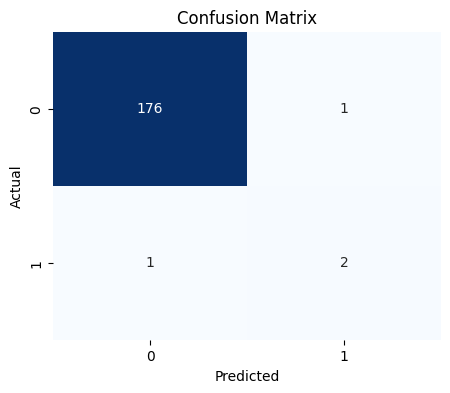

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       177
           1       0.67      0.67      0.67         3

    accuracy                           0.99       180
   macro avg       0.83      0.83      0.83       180
weighted avg       0.99      0.99      0.99       180

Accuracy: 0.9889
Precision: 0.6667
Recall: 0.6667
F1 Score: 0.6667
AUC: 0.9925


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_test, y_test_pred))

# Accuracy, Precision, Recall, F1, AUC
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

ROC Curve


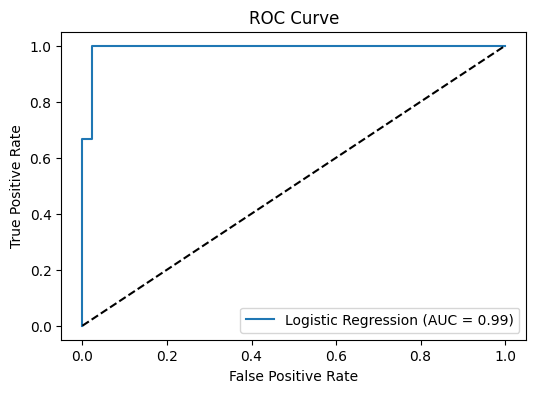

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_test_pred[:10],
    'Probability': y_test_proba[:10]
})
print(results)

   Actual  Predicted   Probability
0       0          0  2.370707e-02
1       0          0  3.236659e-03
2       0          0  5.907851e-07
3       0          0  9.240377e-04
4       0          0  2.464248e-07
5       0          0  5.420971e-04
6       0          0  1.182848e-07
7       0          0  2.715591e-04
8       0          0  5.976008e-05
9       0          0  7.851661e-05


Improving Model Performance

In [ ]:
# Use balanced class weights
model_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
model_balanced.fit(X_train, y_train)
# Then re‑evaluate.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age',
                                                   'daily_social_media_hours',
                                                   'sleep_hours',
                                                   'screen_time_before_sleep',
                                                   'academic_performance',
                                                   'physical_activity',
                                                   'stress_level',
                                                   'anxiety_level',
                                                   'addiction_level']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'platform_usage',
                                                   'social_interaction_level'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

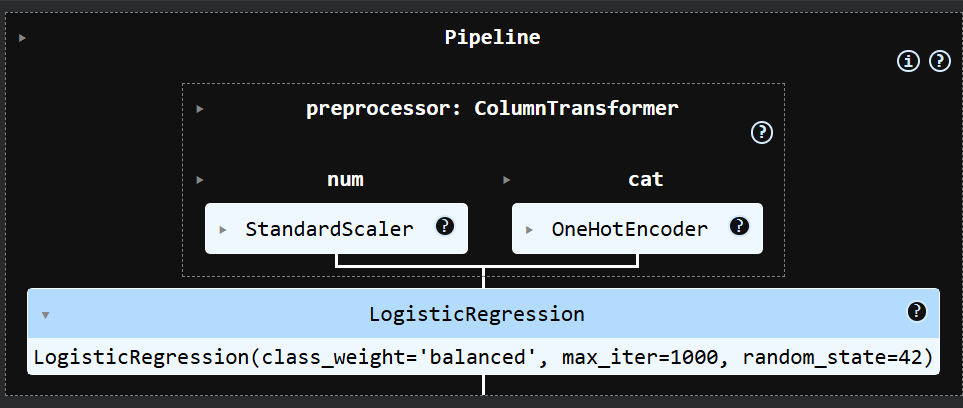